# Customer Churn Prediction & Retention Intelligence System

## Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv("../data/raw/IBM_Telco_customer_churn_IBM_dataset.csv")

df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
).fillna(0)

print("Dataset shape:", df.shape)

Dataset shape: (7043, 33)


In [25]:
service_columns = [
    "Phone Service",
    "Multiple Lines",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies"
]

df["Service Count"] = (
    df[service_columns].eq("Yes").sum(axis=1)
    + df["Internet Service"].ne("No").astype(int)
)

df[["Service Count", "Churn Value"]].head()

,Service Count,Churn Value
0,4,1
1,2,1
2,6,1
3,7,1
4,7,1


In [26]:
df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

print(df["Tenure Group"].value_counts().sort_index())

Tenure Group
0-12 months     2186
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64


In [27]:
tenure_group_churn = (
    df.groupby("Tenure Group", observed=False)["Churn Value"]
      .mean()
      .mul(100)
)

print(tenure_group_churn)

Tenure Group
0-12 months     47.438243
13-24 months    28.710938
25-48 months    20.388959
49-72 months     9.513176
Name: Churn Value, dtype: float64


In [28]:
service_count_churn = (
    df.groupby("Service Count")["Churn Value"]
      .agg(["count", "mean"])
      .rename(columns={"mean": "churn_rate"})
)

service_count_churn["churn_rate"] *= 100

service_count_churn

,count,churn_rate
Service Count,,
1,1264,10.917722
2,859,30.966240
3,846,44.917258
4,965,36.476684
5,922,31.344902
6,908,25.550661
7,676,22.485207
8,395,12.405063
9,208,5.288462


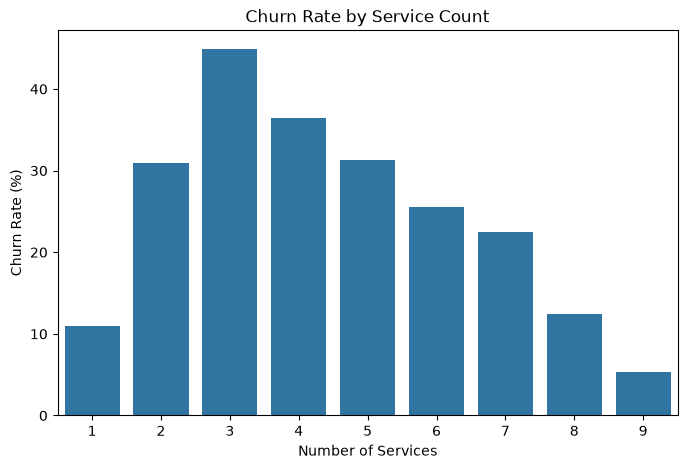

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=service_count_churn.index,
    y=service_count_churn["churn_rate"]
)

plt.xlabel("Number of Services")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Service Count")
plt.show()

In [30]:
features = [
    "Tenure Months", "Monthly Charges", "Total Charges", "CLTV",
    "Partner", "Dependents", "Senior Citizen", "Gender",
    "Phone Service", "Multiple Lines", "Internet Service",
    "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies",
    "Contract", "Paperless Billing", "Payment Method","Service Count",
    "Tenure Group"
]

X = df[features]
y = df["Churn Value"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7043, 22)
Target: (7043,)


## Feature Engineering — Summary

### Engineered Features

1. Service Count
   - Counts the customer's subscribed service options.
   - Candidate feature; usefulness will be evaluated during model comparison.

2. Tenure Group
   - Groups customer tenure into four ranges.
   - Candidate feature derived from Tenure Months; usefulness will be evaluated during model comparison.

### Validation
- Original features: 20
- Engineered features: 2
- Total candidate features: 22
- Missing values in X: 0
- Target: Churn Value

In [13]:
features = [
    "Tenure Months", "Monthly Charges", "Total Charges", "CLTV",
    "Partner", "Dependents", "Senior Citizen", "Gender",
    "Phone Service", "Multiple Lines", "Internet Service",
    "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies",
    "Contract", "Paperless Billing", "Payment Method"
]

X = df[features]
y = df["Churn Value"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7043, 20)
Target: (7043,)


In [31]:
numeric_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

for col in numeric_cols:
    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((X[col] < lower) | (X[col] > upper)).sum()

    print(f"{col}:")
    print(f"  Lower bound: {lower:.2f}")
    print(f"  Upper bound: {upper:.2f}")
    print(f"  Potential outliers: {count}\n")

Tenure Months:
  Lower bound: -60.00
  Upper bound: 124.00
  Potential outliers: 0

Monthly Charges:
  Lower bound: -46.02
  Upper bound: 171.38
  Potential outliers: 0

Total Charges:
  Lower bound: -4683.52
  Upper bound: 8868.67
  Potential outliers: 0

CLTV:
  Lower bound: 601.75
  Upper bound: 8247.75
  Potential outliers: 0



### Outlier Investigation

- Method: Interquartile Range (IQR).
- Features checked: Tenure Months, Monthly Charges, Total Charges, CLTV.
- Result: No potential outliers were identified using the 1.5 × IQR rule.
- Decision: No outlier removal or capping based on this analysis.
- Limitation: IQR does not detect every possible data-quality problem.

In [24]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

In [32]:
modeling_df = X.copy()
modeling_df["Churn Value"] = y

modeling_df.to_csv(
    "../data/processed/churn_modeling_dataset.csv",
    index=False
)

print("Saved shape:", modeling_df.shape)
print("Saved to data/processed/churn_modeling_dataset.csv")

Saved shape: (7043, 23)
Saved to data/processed/churn_modeling_dataset.csv
